SKILLING -1:
Implement an image-quality enhancement pipeline that applies adaptive histogram equalization followed by bilateral filtering and dynamic Otsu-thresholding. Compare the preprocessing results on 5 different noisy images


Using images: ['img1.jpg', 'img2.jpg', 'img3.jpg', 'img4.jpg', 'img5.jpg']


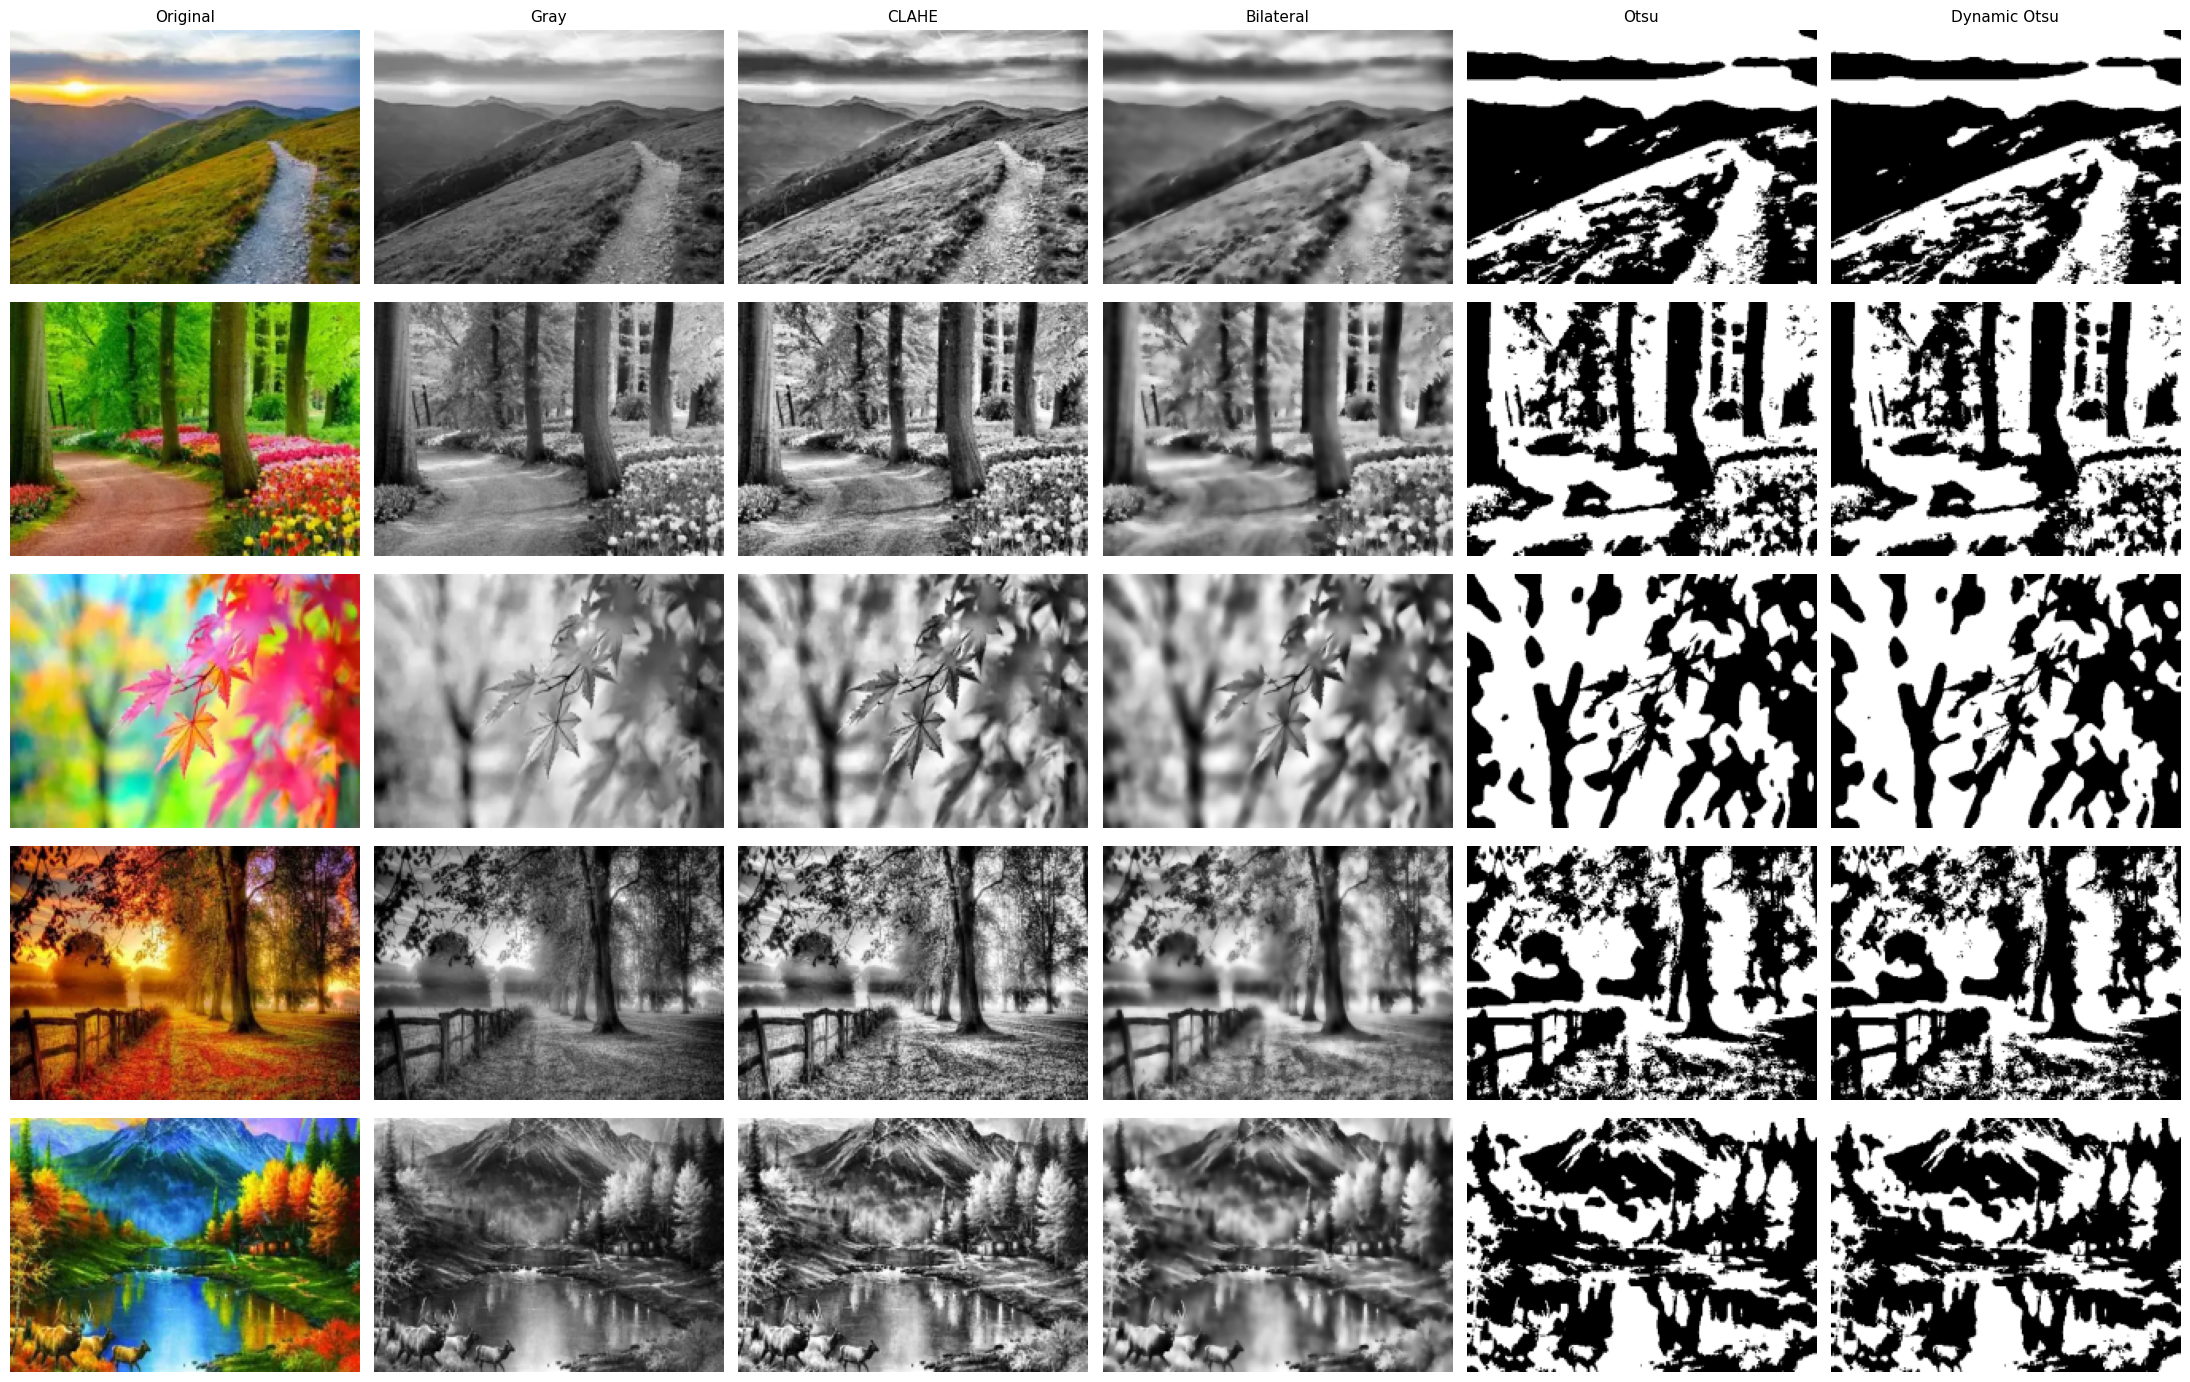

In [3]:
!pip -q install opencv-python-headless
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# ----------------------------
# Resize helper (uniform size)
# ----------------------------
def resize_to(gray_or_rgb, target_w=220, target_h=160):
    return cv2.resize(gray_or_rgb, (target_w, target_h), interpolation=cv2.INTER_AREA)

# ----------------------------
# Noise estimate for Dynamic Otsu
# ----------------------------
def estimate_noise_sigma(gray_img):
    blur = cv2.GaussianBlur(gray_img, (3, 3), 0)
    residual = gray_img.astype(np.float32) - blur.astype(np.float32)
    mad = np.median(np.abs(residual - np.median(residual)))
    return float(1.4826 * mad)

# ----------------------------
# Pipeline: CLAHE -> Bilateral -> Dynamic Otsu
# ----------------------------
def enhancement_pipeline(bgr_img):
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)

    gray_bilat = cv2.bilateralFilter(
        gray_clahe, d=9, sigmaColor=60, sigmaSpace=60
    )

    otsu_thr, otsu_bin = cv2.threshold(
        gray_bilat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    sigma = estimate_noise_sigma(gray)
    shift = np.clip((sigma - 5.0) * 0.8, -12, 12)
    dyn_thr = np.clip(otsu_thr + shift, 0, 255)

    _, dyn_otsu_bin = cv2.threshold(
        gray_bilat, dyn_thr, 255, cv2.THRESH_BINARY
    )

    return gray, gray_clahe, gray_bilat, otsu_bin, dyn_otsu_bin, otsu_thr, dyn_thr

# ============================================================
# Load any 5 images from local folder (VS Code)
# ============================================================
IMAGE_DIR = "images"  # put images here

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Folder '{IMAGE_DIR}' not found")

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(valid_ext)
]

if len(image_files) < 5:
    raise ValueError(
        f"Place at least 5 images in '{IMAGE_DIR}'. Found {len(image_files)}"
    )

image_files = image_files[:5]

fixed = []
for i, src in enumerate(image_files, start=1):
    src_path = os.path.join(IMAGE_DIR, src)
    dst = f"img{i}.jpg"
    shutil.copy(src_path, dst)
    fixed.append(dst)

print("Using images:", fixed)

# ============================================================
# Create 5 × 6 comparison grid
# ============================================================
col_titles = ["Original", "Gray", "CLAHE", "Bilateral", "Otsu", "Dynamic Otsu"]
TARGET_W, TARGET_H = 220, 160

fig = plt.figure(figsize=(22, 14))
plot_index = 1

for r, img_name in enumerate(fixed, start=1):
    bgr = cv2.imread(img_name)
    if bgr is None:
        print(f"Skipping unreadable file: {img_name}")
        continue

    gray, clahe_img, bilat, otsu_bin, dyn_bin, t1, t2 = enhancement_pipeline(bgr)

    orig_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    row_imgs = [
        resize_to(orig_rgb, TARGET_W, TARGET_H),
        resize_to(gray, TARGET_W, TARGET_H),
        resize_to(clahe_img, TARGET_W, TARGET_H),
        resize_to(bilat, TARGET_W, TARGET_H),
        resize_to(otsu_bin, TARGET_W, TARGET_H),
        resize_to(dyn_bin, TARGET_W, TARGET_H),
    ]

    for c in range(6):
        ax = plt.subplot(5, 6, plot_index)
        plot_index += 1

        if r == 1:
            ax.set_title(col_titles[c], fontsize=11)

        if c == 0:
            plt.imshow(row_imgs[c])
        else:
            plt.imshow(row_imgs[c], cmap="gray")

        if c == 0:
            ax.set_ylabel(
                f"Image {r}\nOtsu={t1:.0f}\nDyn={t2:.0f}",
                fontsize=10
            )

        ax.axis("off")

plt.tight_layout()
plt.show()
